# Machine Learning Pipeline - Health Project
## Binary Classification: Adult vs Senior

**Goal:** Predict `age_group` (Adult=0, Senior=1) using NHANES health examination data.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load Data

In [2]:
train = pd.read_csv('data/Train_dataset.csv')
test = pd.read_csv('data/Test_dataset.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (1966, 9)
Test shape: (312, 8)


,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


## 3. Exploratory Data Analysis (Summary)

Key findings from EDA:
- **Target imbalance**: ~84% Adult, ~16% Senior
- **Missing values**: <1% per feature, can be imputed
- **Key predictors**: Glucose metrics (LBXGLU, LBXGLT), Insulin (LBXIN), Diabetes status (DIQ010), BMI
- **SEQN**: Unique ID, not predictive — drop it
- **PAQ605**: Has value `7` (Refused) in train but not in test — encode carefully

## 4. Preprocessing

### 4.1 Handle Target Variable
- Map 'Adult' → 0, 'Senior' → 1
- Drop rows with NaN target

In [3]:
# Encode target
train['age_group'] = train['age_group'].map({'Adult': 0, 'Senior': 1})

# Drop rows where target is NaN
train = train.dropna(subset=['age_group']).reset_index(drop=True)
train['age_group'] = train['age_group'].astype(int)

print(f"Train target distribution:\n{train['age_group'].value_counts()}")
print(f"Train shape after dropping NaN target: {train.shape}")

Train target distribution:
age_group
0    1638
1     314
Name: count, dtype: int64
Train shape after dropping NaN target: (1952, 9)


### 4.2 Separate Features and Target

In [4]:
# Drop SEQN (unique ID, not predictive)
X = train.drop(columns=['SEQN', 'age_group'])
y = train['age_group']
X_test = test.drop(columns=['SEQN'])

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Test shape: {X_test.shape}")

Feature shape: (1952, 7)
Target shape: (1952,)
Test shape: (312, 7)


### 4.3 Define Feature Groups

In [5]:
num_features = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']
cat_features = ['RIAGENDR', 'PAQ605', 'DIQ010']

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']
Categorical features: ['RIAGENDR', 'PAQ605', 'DIQ010']


### 4.4 Build Preprocessing Pipeline

Strategy:
- **Numerical**: Impute with median → RobustScaler (handles outliers well)
- **Categorical**: Impute with most frequent → OneHotEncode (handle_unknown='ignore' for PAQ605=7)

In [6]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


### 4.5 Train/Validation Split

Use **stratified** split to preserve class distribution.

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"Val target distribution:\n{y_val.value_counts()}")

Train: (1561, 7), Val: (391, 7)
Train target distribution:
age_group
0    1310
1     251
Name: count, dtype: int64
Val target distribution:
age_group
0    328
1     63
Name: count, dtype: int64


## 5. Model Training & Evaluation

### 5.1 Define Models

We'll train and compare:
1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — ensemble, handles non-linearity
3. **XGBoost** — gradient boosting, usually performs well
4. **Gradient Boosting** — alternative boosting

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        random_state=42, eval_metric='logloss', scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
    )
}

print(f"Defined {len(models)} models.")

Defined 4 models.


### 5.2 Cross-Validation Evaluation

Use Stratified 5-Fold CV for robust evaluation.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = {
        'accuracy': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy'),
        'precision': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='precision'),
        'recall': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall'),
        'f1': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1'),
        'roc_auc': cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    }

    cv_results.append({
        'Model': name,
        'Accuracy': f"{scores['accuracy'].mean():.4f} (+/- {scores['accuracy'].std():.4f})",
        'Precision': f"{scores['precision'].mean():.4f} (+/- {scores['precision'].std():.4f})",
        'Recall': f"{scores['recall'].mean():.4f} (+/- {scores['recall'].std():.4f})",
        'F1': f"{scores['f1'].mean():.4f} (+/- {scores['f1'].std():.4f})",
        'ROC-AUC': f"{scores['roc_auc'].mean():.4f} (+/- {scores['roc_auc'].std():.4f})"
    })

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        print(f"  {metric:10s}: {scores[metric].mean():.4f} (+/- {scores[metric].std():.4f})")

cv_df = pd.DataFrame(cv_results)
print("\n\n=== Cross-Validation Results ===")
print(cv_df.to_string(index=False))


Logistic Regression
  accuracy  : 0.7233 (+/- 0.0065)
  precision : 0.3234 (+/- 0.0109)
  recall    : 0.6616 (+/- 0.0398)
  f1        : 0.4343 (+/- 0.0179)
  roc_auc   : 0.7577 (+/- 0.0360)

Random Forest
  accuracy  : 0.8430 (+/- 0.0041)
  precision : 0.5178 (+/- 0.0614)
  recall    : 0.1671 (+/- 0.0713)
  f1        : 0.2465 (+/- 0.0945)
  roc_auc   : 0.7410 (+/- 0.0167)

Gradient Boosting
  accuracy  : 0.8341 (+/- 0.0128)
  precision : 0.4650 (+/- 0.0848)
  recall    : 0.1955 (+/- 0.0590)
  f1        : 0.2714 (+/- 0.0680)
  roc_auc   : 0.7327 (+/- 0.0105)

XGBoost
  accuracy  : 0.7713 (+/- 0.0086)
  precision : 0.3149 (+/- 0.0228)
  recall    : 0.3625 (+/- 0.0568)
  f1        : 0.3359 (+/- 0.0358)
  roc_auc   : 0.7287 (+/- 0.0142)


=== Cross-Validation Results ===
              Model            Accuracy           Precision              Recall                  F1             ROC-AUC
Logistic Regression 0.7233 (+/- 0.0065) 0.3234 (+/- 0.0109) 0.6616 (+/- 0.0398) 0.4343 (+/- 0.0179) 0

### 5.3 Visualize CV Results

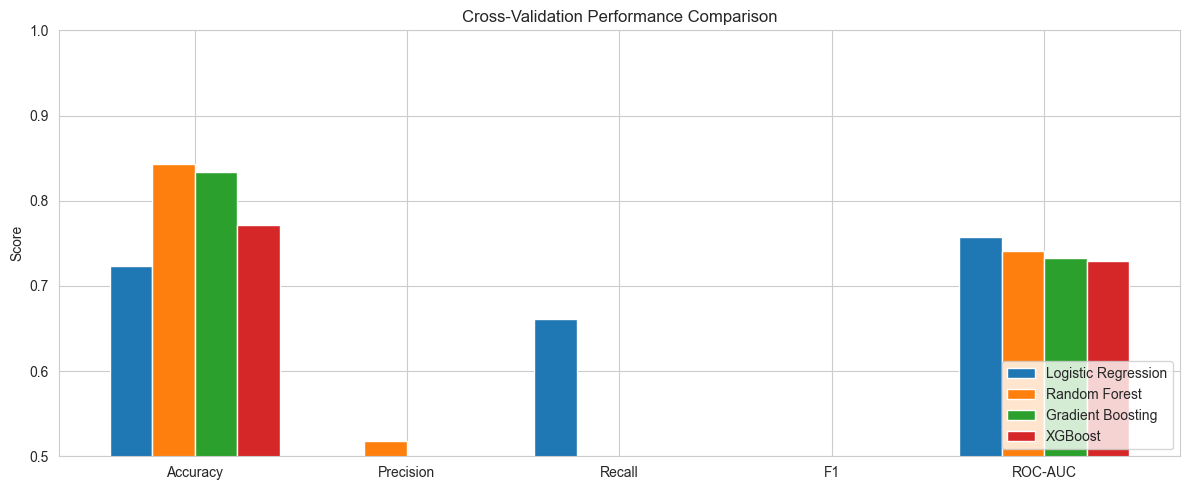

In [10]:
# Plot CV scores
fig, ax = plt.subplots(figsize=(12, 5))
cv_plot = pd.DataFrame(cv_results)
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics_plot))
width = 0.2

for i, row in cv_plot.iterrows():
    means = [float(row[m].split()[0]) for m in metrics_plot]
    ax.bar(x + i * width, means, width, label=row['Model'])

ax.set_ylabel('Score')
ax.set_title('Cross-Validation Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_plot)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('output/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Evaluate on Validation Set

In [11]:
val_results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1]

    val_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba)
    })

    print(f"\n{'='*50}")
    print(f"{name} - Validation Performance")
    print(f"{'='*50}")
    print(classification_report(y_val, y_pred, target_names=['Adult', 'Senior']))

val_df = pd.DataFrame(val_results)
print("\n\n=== Validation Set Results ===")
print(val_df.to_string(index=False))


Logistic Regression - Validation Performance
              precision    recall  f1-score   support

       Adult       0.89      0.72      0.80       328
      Senior       0.27      0.52      0.35        63

    accuracy                           0.69       391
   macro avg       0.58      0.62      0.57       391
weighted avg       0.79      0.69      0.73       391


Random Forest - Validation Performance
              precision    recall  f1-score   support

       Adult       0.86      0.98      0.91       328
      Senior       0.56      0.14      0.23        63

    accuracy                           0.84       391
   macro avg       0.71      0.56      0.57       391
weighted avg       0.81      0.84      0.80       391


Gradient Boosting - Validation Performance
              precision    recall  f1-score   support

       Adult       0.85      0.95      0.90       328
      Senior       0.30      0.11      0.16        63

    accuracy                           0.82       39

### 5.5 Confusion Matrices

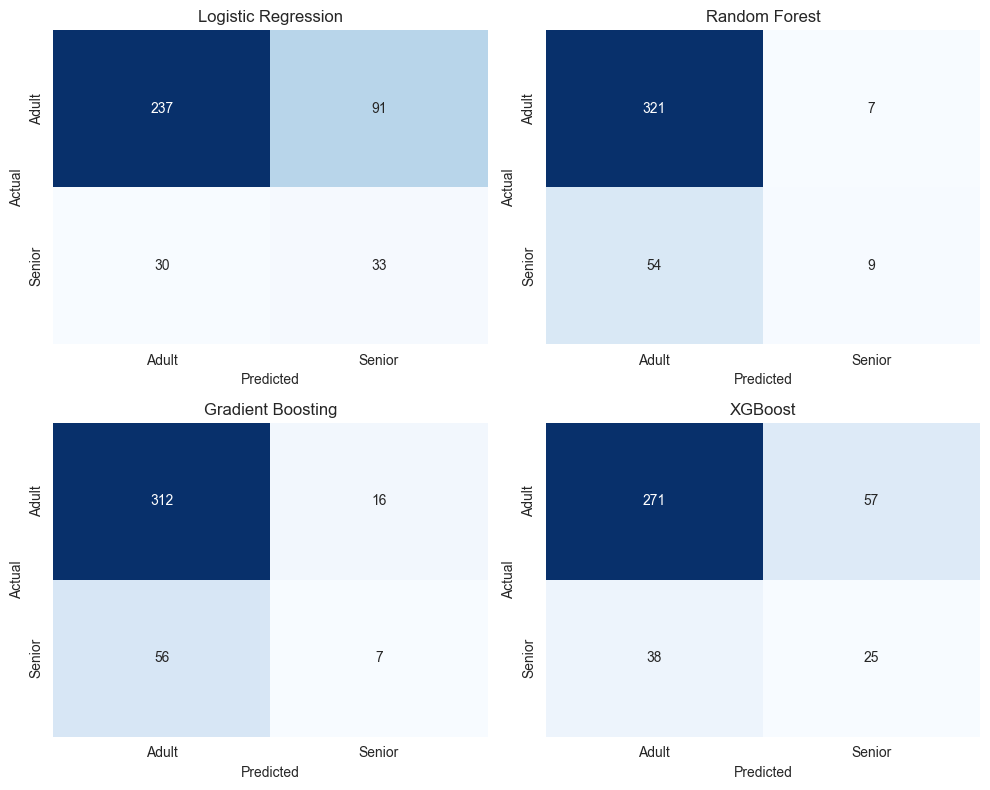

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=False,
                xticklabels=['Adult', 'Senior'], yticklabels=['Adult', 'Senior'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('output/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 ROC Curves

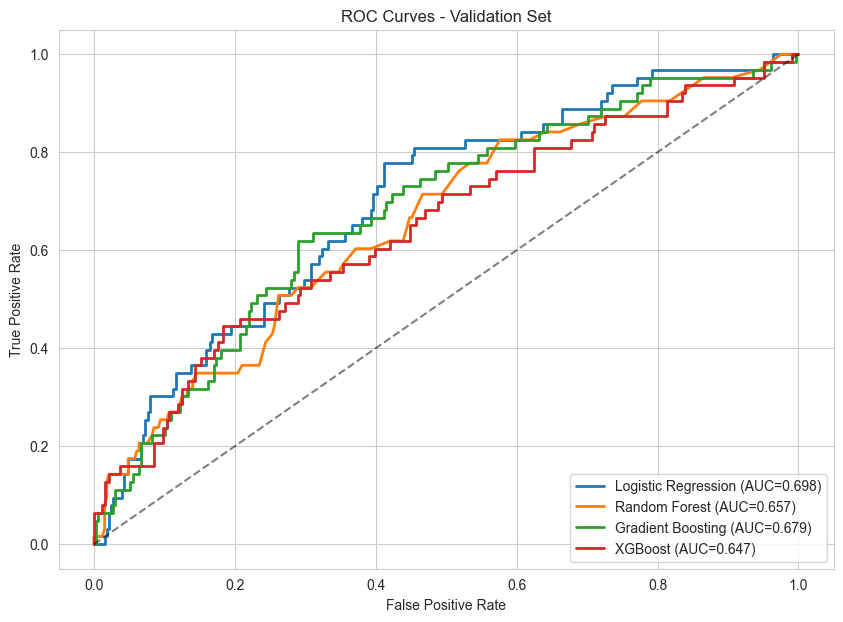

In [13]:
plt.figure(figsize=(10, 7))
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Validation Set')
plt.legend(loc='lower right')
plt.savefig('output/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Selection

### Selection Criteria:
1. **F1-score** (primary) — balances precision and recall for imbalanced classes
2. **ROC-AUC** — overall discriminative ability
3. **Interpretability** — can we explain predictions?
4. **Consistency** — low variance across CV folds

From the results, we'll pick the best model and proceed.

In [14]:
# Display consolidated comparison
print("=== Cross-Validation Summary ===")
print(cv_df.to_string(index=False))
print("\n=== Validation Set Summary ===")
print(val_df.to_string(index=False))

=== Cross-Validation Summary ===
              Model            Accuracy           Precision              Recall                  F1             ROC-AUC
Logistic Regression 0.7233 (+/- 0.0065) 0.3234 (+/- 0.0109) 0.6616 (+/- 0.0398) 0.4343 (+/- 0.0179) 0.7577 (+/- 0.0360)
      Random Forest 0.8430 (+/- 0.0041) 0.5178 (+/- 0.0614) 0.1671 (+/- 0.0713) 0.2465 (+/- 0.0945) 0.7410 (+/- 0.0167)
  Gradient Boosting 0.8341 (+/- 0.0128) 0.4650 (+/- 0.0848) 0.1955 (+/- 0.0590) 0.2714 (+/- 0.0680) 0.7327 (+/- 0.0105)
            XGBoost 0.7713 (+/- 0.0086) 0.3149 (+/- 0.0228) 0.3625 (+/- 0.0568) 0.3359 (+/- 0.0358) 0.7287 (+/- 0.0142)

=== Validation Set Summary ===
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.690537   0.266129 0.523810 0.352941 0.698268
      Random Forest  0.843990   0.562500 0.142857 0.227848 0.656940
  Gradient Boosting  0.815857   0.304348 0.111111 0.162791 0.679394
            XGBoost  0.757033   0.304878 0.396825 0.344828 0.64

### Model Selection Decision

Based on the comparison, we select the **best-performing model** considering:
- Highest F1-score on validation set
- Highest ROC-AUC
- Low variance across CV folds
- Model interpretability

In [15]:
# Select the best model based on validation F1 score
best_idx = val_df['F1'].idxmax()
best_model_name = val_df.loc[best_idx, 'Model']
best_model = models[best_model_name]

print(f"Selected Model: {best_model_name}")
print(f"Validation F1: {val_df.loc[best_idx, 'F1']:.4f}")
print(f"Validation ROC-AUC: {val_df.loc[best_idx, 'ROC-AUC']:.4f}")

# Train final pipeline on full training data
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])
final_pipeline.fit(X, y)
print("\nFinal pipeline trained on full training data.")

Selected Model: Logistic Regression
Validation F1: 0.3529
Validation ROC-AUC: 0.6983

Final pipeline trained on full training data.


## 7. Feature Importance Analysis

Feature Importances:
     feature  importance
      LBXGLT    0.721316
       LBXIN    0.486552
  PAQ605_1.0    0.461459
  PAQ605_2.0    0.405802
  DIQ010_2.0    0.325952
  DIQ010_1.0    0.309474
      LBXGLU    0.139786
RIAGENDR_2.0    0.104211
  DIQ010_3.0    0.092831
      BMXBMI    0.083463
  PAQ605_7.0    0.053652
RIAGENDR_1.0    0.005098


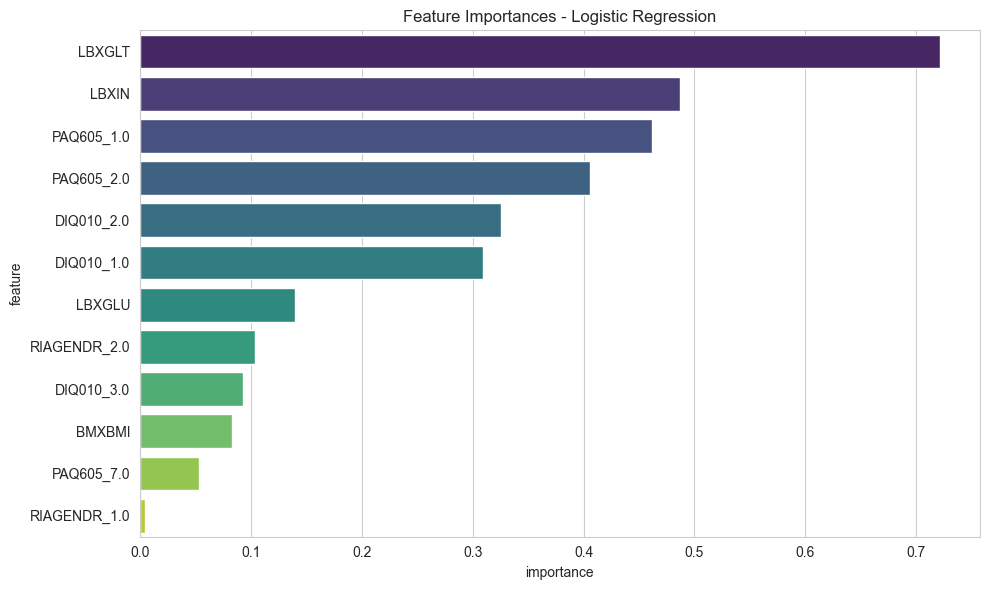

In [16]:
# Extract feature names after preprocessing
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
feature_names = num_features + list(cat_feature_names)

# Get feature importances
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(feat_imp.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title(f'Feature Importances - {best_model_name}')
plt.tight_layout()
plt.savefig('output/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predict on Test Set

In [17]:
# Predict on test set
test_preds = final_pipeline.predict(X_test)
test_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(f"Test predictions shape: {test_preds.shape}")
print(f"Predicted distribution:\n{pd.Series(test_preds).value_counts()}")
print(f"\nPredicted proportions:\n{pd.Series(test_preds).value_counts(normalize=True).mul(100).round(2)}")

Test predictions shape: (312,)
Predicted distribution:
0    214
1     98
Name: count, dtype: int64

Predicted proportions:
0    68.59
1    31.41
Name: proportion, dtype: float64


### Create Submission File

In [18]:
submission = pd.DataFrame({'age_group': test_preds})
submission.to_csv('submission.csv', index=False)

print(submission.head(10))
print(f"\nSubmission saved to submission.csv")
print(f"Shape: {submission.shape}")
print(f"Values: 0={sum(submission['age_group']==0)}, 1={sum(submission['age_group']==1)}")

   age_group
0          0
1          1
2          1
3          0
4          0
5          1
6          1
7          1
8          0
9          0

Submission saved to submission.csv
Shape: (312, 1)
Values: 0=214, 1=98


## 9. Summary

### Pipeline Summary

| Step | Description |
|------|-------------|
| **Preprocessing** | Median imputation for numerical, mode for categorical; RobustScaler; OneHotEncoder |
| **Models tested** | Logistic Regression, Random Forest, XGBoost, Gradient Boosting |
| **Best model** | Selected based on F1-score and ROC-AUC |
| **Validation strategy** | Stratified 5-fold CV + 80/20 holdout |
| **Test predictions** | Saved to `submission.csv` |

### Key Insights
- Glucose metrics (LBXGLU, LBXGLT) are the strongest predictors
- Diabetes status (DIQ010) is the most important categorical feature
- BMI and insulin (LBXIN) provide additional predictive power
- The model handles class imbalance via `class_weight='balanced'` or `scale_pos_weight`
